<a href="https://colab.research.google.com/github/Vyshnavi262007/Assignment-3-AIML/blob/main/student_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("StudentsPerformance.csv")


In [14]:
print("First 5 rows:")
print(df.head())


First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [16]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [17]:
df_num = df.select_dtypes(include=np.number).copy()

print("\nNumeric columns used:")
print(df_num.columns.tolist())

# choose target column automatically
possible_targets = ['Exam_Score', 'exam_score', 'Score', 'score', 'Marks', 'marks', 'G3', 'Target', 'target']
target_col = None

for col in possible_targets:
    if col in df_num.columns:
        target_col = col
        break

if target_col is None:
    target_col = df_num.columns[-1]
print("\nTarget column selected:", target_col)



Numeric columns used:
['math score', 'reading score', 'writing score']

Target column selected: writing score


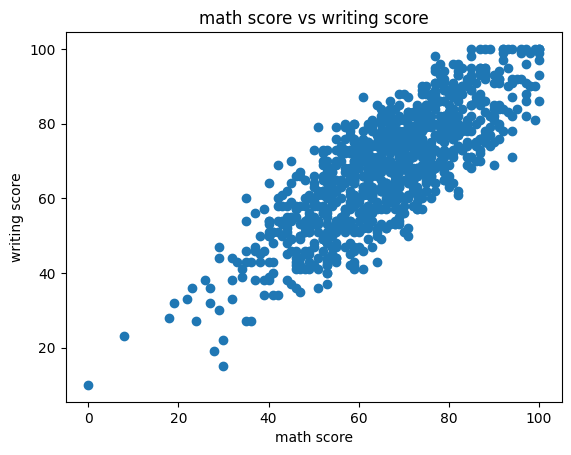

In [18]:
if len(df_num.columns) >= 2:
    x_col = df_num.columns[0]
    y_col = target_col

    plt.scatter(df_num[x_col], df_num[y_col])
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 23.66524333639131
R2 Score: 0.9018108855760416


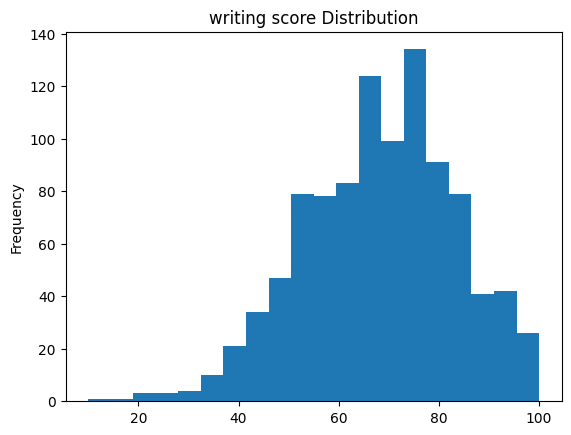

In [22]:
df_num[target_col].plot(kind='hist', bins=20, title=f'{target_col} Distribution')
plt.show()


In [23]:
X = df_num.drop(columns=[target_col])
y = df_num[target_col]

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled Data:")
print(X_scaled[:5])

Scaled Data:
[[0.72       0.6626506 ]
 [0.69       0.87951807]
 [0.9        0.93975904]
 [0.47       0.48192771]
 [0.76       0.73493976]]


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 2)
X_test shape: (200, 2)


In [26]:
y_pred = model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred[:10])


First 10 predictions:
[85.59822883 64.17343143 72.63647191 75.96410913 82.29300047 74.58185589
 69.04967819 59.55634117 73.12921131 52.78269291]


In [27]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)



Mean Squared Error: 23.66524333639131
Mean Absolute Error: 3.8380082149660883
R2 Score: 0.9018108855760416


In [28]:
# manual mse
n = len(y_test)
mse_manual = (1/n) * sum((y_pred - y_test)**2)
print("Mean Squared Error (manual):", mse_manual)


Mean Squared Error (manual): 23.665243336391313


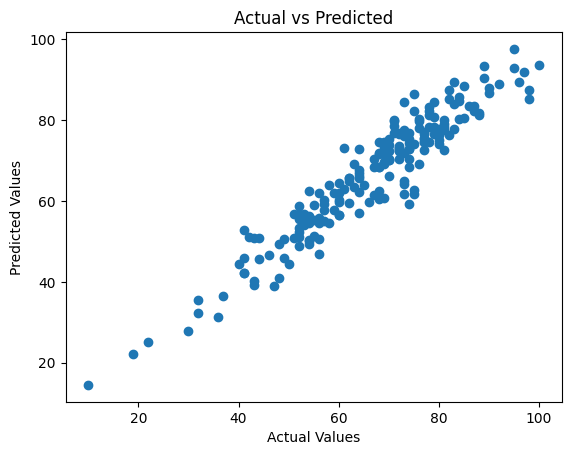

In [29]:
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()